In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Reading data
#/rac_featurization_frame.csv
# /zeoplus_features.csv
#/qmof_labels.csv
# /merged_edited.csv

#f-Z-0-all, mc-chi-0-all, ASA_A^2, Density
CSV_PATH = Path("/merged_edited.csv")

df = pd.read_csv(CSV_PATH)
#num_df = df.select_dtypes(include='number')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16482 entries, 0 to 16481
Columns: 185 entries, f-chi-0-all to outputs.pbe.bandgap
dtypes: float64(185)
memory usage: 23.3 MB


In [2]:
# visualizations demonstrate understanding of label (target feature) characteristics.
# Histogram
# Top correlated feature to label (Heat map) and each others
# box plot for top correlated feature to label

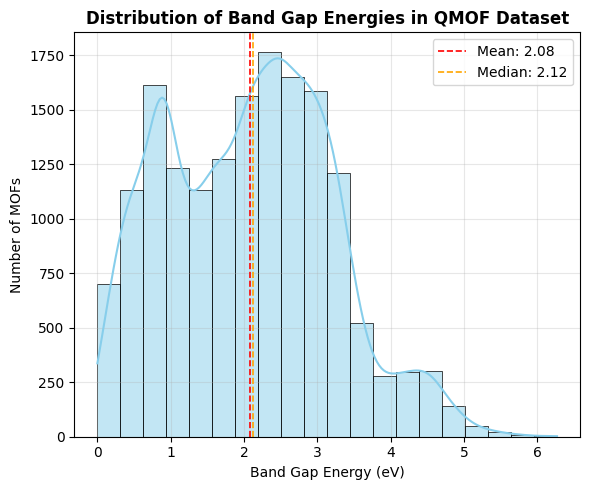

In [65]:
# df['outputs.pbe.bandgap'].hist(bins = 15)
# plt.title('Distribution of Band Gap Energies in QMOF Dataset')
# plt.xlabel('Band Gap Energy (eV)')
# plt.ylabel('Number of MOFs')

# Display the plot
mean_val = df['outputs.pbe.bandgap'].mean()
median_val = df['outputs.pbe.bandgap'].median()

# Create histogram with KDE (optional)
plt.figure(figsize=(6, 5))
sns.histplot(df['outputs.pbe.bandgap'], bins=20, kde=True, color='skyblue', edgecolor='black', linewidth=0.5)

# Add vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='orange', linestyle='--', linewidth=1.2, label=f'Median: {median_val:.2f}')

# Add labels and title
plt.title('Distribution of Band Gap Energies in QMOF Dataset', fontsize=12, fontweight='bold')
plt.xlabel('Band Gap Energy (eV)')
plt.ylabel('Number of MOFs')

# Add legend and grid
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
df.info()
features = ['outputs.pbe.bandgap', 'f-Z-0-all', 'mc-chi-0-all', 'ASA_A^2', 'Density']

# Compute base descriptive statistics
stats = df[features].describe().T

# Add additional statistics
stats['variance'] = df[features].var()
stats['skewness'] = df[features].skew()
stats['kurtosis'] = df[features].kurt()
stats['range'] = stats['max'] - stats['min']

# Reorder columns for clarity
stats = stats[['count', 'mean', 'std', 'variance', 'min', '25%', '50%', '75%', 'max', 'range', 'skewness', 'kurtosis']]

# Display nicely
stats.round(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16482 entries, 0 to 16481
Columns: 185 entries, f-chi-0-all to outputs.pbe.bandgap
dtypes: float64(185)
memory usage: 23.3 MB


,count,mean,std,variance,min,25%,50%,75%,max,range,skewness,kurtosis
outputs.pbe.bandgap,16482.0,2.077,1.131,1.280000e+00,0.001,1.087,2.121,2.879,6.271,6.269,0.251,-0.467
f-Z-0-all,16482.0,4992.800,5742.553,3.297692e+07,300.000,1753.000,2874.000,5688.750,158952.000,158652.000,5.372,68.649
mc-chi-0-all,16482.0,2.686,0.875,7.650000e-01,0.624,2.402,2.722,3.534,6.452,5.828,-0.420,0.252
ASA_A^2,16482.0,210.988,440.119,1.937049e+05,0.000,0.000,0.000,214.071,3983.750,3983.750,2.868,9.515
Density,16482.0,1.636,0.636,4.050000e-01,0.087,1.259,1.663,2.007,5.436,5.349,0.159,0.423


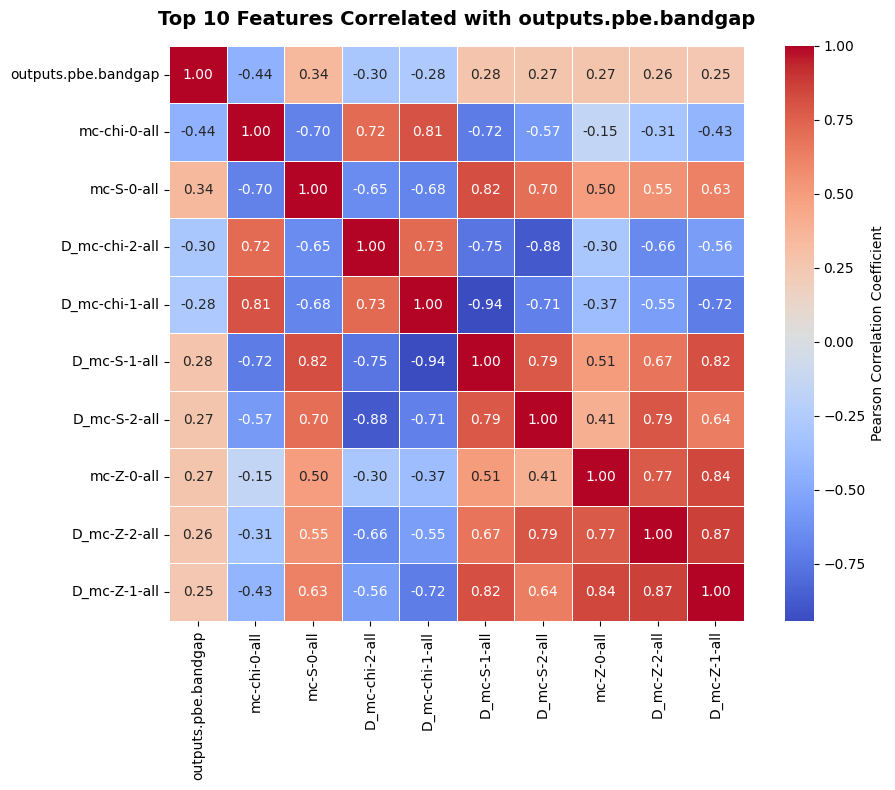

In [24]:
target_feature = "outputs.pbe.bandgap"
top_n = 10  # number of top correlated features to visualize
corr_method = "pearson"  # or "spearman"


# Compute correlations of all numeric features with the target
corr_to_target = df.corr(method=corr_method)[target_feature].dropna()

# Sort by absolute correlation strength (descending)
corr_to_target = corr_to_target.abs().sort_values(ascending=False)

# Display top correlated features
# print(f"\nTop {top_n} features correlated with '{target_feature}' ({corr_method.title()}):\n")
# print(corr_to_target.head(top_n).round(3))

# Select the top correlated features (including the target itself)
top_features = corr_to_target.head(top_n).index.tolist()


corr_matrix = df[top_features].corr(method=corr_method)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'label': f'{corr_method.title()} Correlation Coefficient'}
)

plt.title(f"Top {top_n} Features Correlated with {target_feature}", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

/tmp/ipython-input-877895698.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


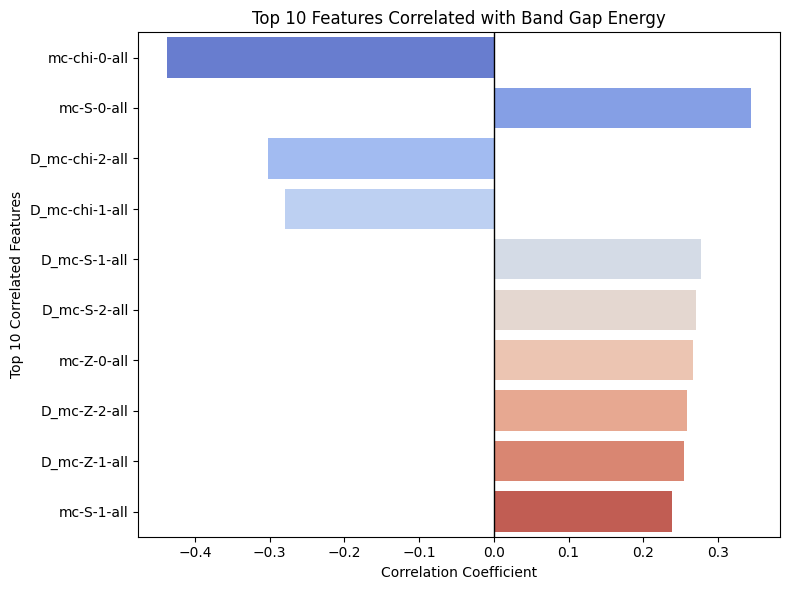

In [40]:
corr_to_target = df.corr(numeric_only=True)[target_feature].dropna()

# Sort by absolute correlation strength (but keep sign)
corr_to_target = corr_to_target.reindex(corr_to_target.abs().sort_values(ascending=False).index)

# Select top 10 features (excluding the target itself)
top_corr_features = corr_to_target[1:11]  # Skip the first (self-correlation)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x=top_corr_features.values,
    y=top_corr_features.index,
    palette='coolwarm',
    orient='h'
)

# Add a vertical line at 0 for reference
plt.axvline(0, color='black', linewidth=1)

# Labels and title
plt.xlabel('Correlation Coefficient')
plt.ylabel('Top 10 Correlated Features')
plt.title('Top 10 Features Correlated with Band Gap Energy')
plt.tight_layout()
plt.show()

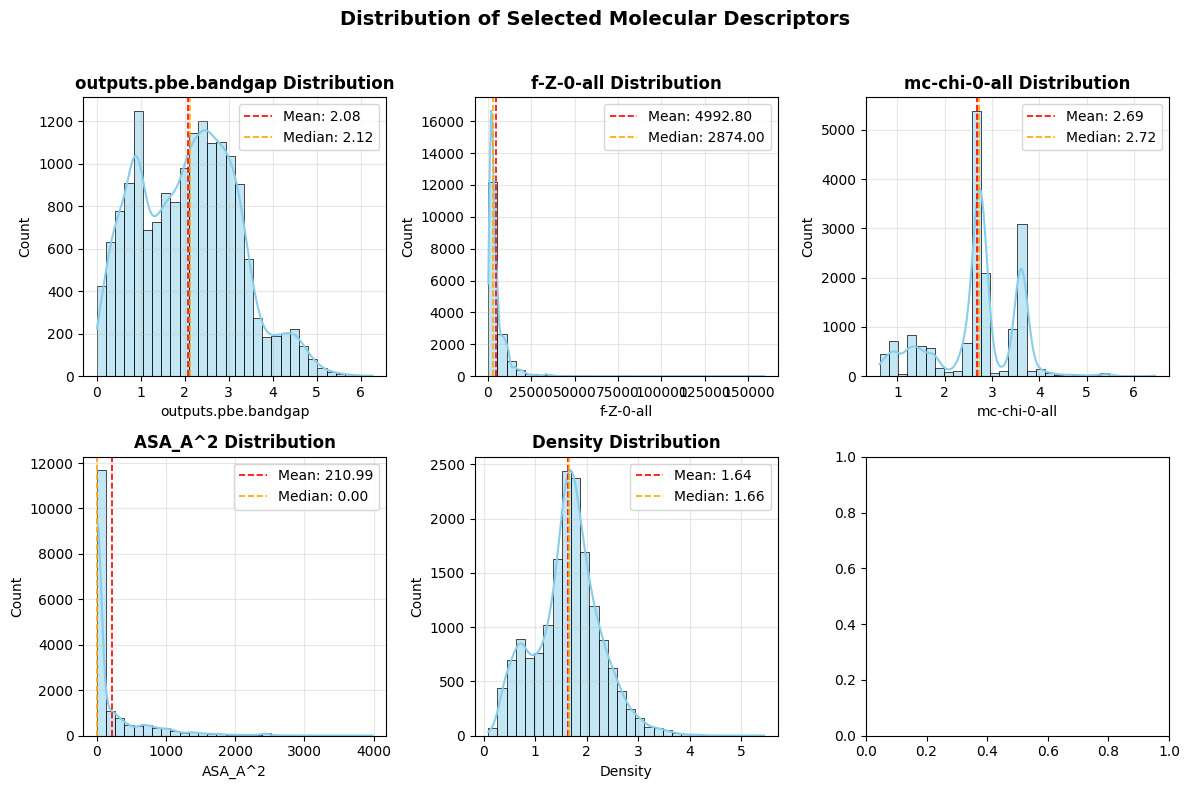

In [63]:
descriptors_to_plot = ['outputs.pbe.bandgap','f-Z-0-all', 'mc-chi-0-all', 'ASA_A^2', 'Density']

# Create subplots (2x2 grid)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Plot histograms with mean and median lines
for i, descriptor in enumerate(descriptors_to_plot):
    ax = axes[i]

    # Create histogram + density

    sns.histplot(df[descriptor], bins=30, kde=True, color='skyblue', ax=ax, edgecolor='black', linewidth=0.5, stat='count')


    # Compute statistics
    mean_val = df[descriptor].mean()
    median_val = df[descriptor].median()

    # Add mean/median lines
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=1.2, label=f'Median: {median_val:.2f}')

    # Formatting
    ax.set_title(f'{descriptor} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(descriptor)
    #ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

# Adjust layout and overall title
plt.suptitle('Distribution of Selected Molecular Descriptors', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [71]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Detect outliers (True/False mask)
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

# Count how many outliers per column
outlier_count = outliers.sum().sort_values(ascending=False)
print(outlier_count.head(10))

NASA_A^2              3333
D_func-T-2-all        2777
POAV_A^3              2614
PONAV_A^3             2534
ASA_A^2               2461
D_mc-S-1-all          2455
D_func-alpha-3-all    2253
func-alpha-0-all      2200
D_lc-S-1-all          2126
D_func-T-3-all        2065
dtype: int64
